In [ ]:

# PART 1: IMPORT LIBRARIES


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:

# PART 2: LOAD DATASETS

customer_df = pd.read_csv('customer_churn.csv')
sales_df = pd.read_csv('sales_data.csv')

print('Datasets Loaded Successfully')


Datasets Loaded Successfully


In [ ]:

# PART 3: DATA EXPLORATION


# Customer Dataset Preview
print(customer_df.head())

# Sales Dataset Preview
print(sales_df.head())

# Dataset Information
print(customer_df.info())
print(sales_df.info())

# Missing Values
print(customer_df.isnull().sum())
print(sales_df.isnull().sum())

# Statistical Summary
print(customer_df.describe())
print(sales_df.describe())


  CustomerID  Tenure  MonthlyCharges  TotalCharges        Contract  \
0     C00001       6              64          1540        One year   
1     C00002      21             113          1753  Month-to-month   
2     C00003      27              31          1455        Two year   
3     C00004      53              29          7150  Month-to-month   
4     C00005      16             185          1023        One year   

      PaymentMethod PaperlessBilling  SeniorCitizen  Churn  
0       Credit Card               No              1      0  
1  Electronic Check              Yes              1      0  
2       Credit Card               No              1      0  
3  Electronic Check               No              1      0  
4  Electronic Check               No              1      0  
         Date     Product  Quantity  Price Customer_ID Region  Total_Sales
0  2024-01-01       Phone         7  37300     CUST001   East       261100
1  2024-01-02  Headphones         4  15406     CUST002  North  

In [ ]:

# PART 4: DATA CLEANING

# Convert Date Column
sales_df['Date'] = pd.to_datetime(sales_df['Date'])

# Create Additional Date Columns
sales_df['Month'] = sales_df['Date'].dt.month_name()
sales_df['Year'] = sales_df['Date'].dt.year

# Rename Customer Column
customer_df.rename(columns={'CustomerID': 'Customer_ID'}, inplace=True)

# Handle Missing Values
customer_df.fillna(0, inplace=True)
sales_df.fillna(0, inplace=True)

# Create Calculated Column
sales_df['Average_Price'] = sales_df['Total_Sales'] / sales_df['Quantity']

print(sales_df.head())


        Date     Product  Quantity  Price Customer_ID Region  Total_Sales  \
0 2024-01-01       Phone         7  37300     CUST001   East       261100   
1 2024-01-02  Headphones         4  15406     CUST002  North        61624   
2 2024-01-03       Phone         2  21746     CUST003   West        43492   
3 2024-01-04  Headphones         1  30895     CUST004   East        30895   
4 2024-01-05      Laptop         8  39835     CUST005  North       318680   

     Month  Year  Average_Price  
0  January  2024        37300.0  
1  January  2024        15406.0  
2  January  2024        21746.0  
3  January  2024        30895.0  
4  January  2024        39835.0  


In [ ]:

# PART 6: CUSTOMER LIFETIME VALUE

customer_ltv = sales_df.groupby('Customer_ID').agg({
    'Total_Sales': 'sum',
    'Quantity': 'sum',
    'Product': 'count'
})

customer_ltv.columns = ['Lifetime_Value', 'Total_Products', 'Total_Orders']

print(customer_ltv.head())


             Lifetime_Value  Total_Products  Total_Orders
Customer_ID                                              
CUST001              261100               7             1
CUST002               61624               4             1
CUST003               43492               2             1
CUST004               30895               1             1
CUST005              318680               8             1


In [ ]:

# PART 7: REGIONAL SALES ANALYSIS

regional_sales = sales_df.groupby('Region')['Total_Sales'].sum()

print(regional_sales)



Region
East     2519639
North    3983635
South    3737852
West     2123922
Name: Total_Sales, dtype: int64


In [ ]:

# =============================================
# PART 8: RETENTION RATE ANALYSIS
# =============================================

if 'Churn' in customer_df.columns:
    retention_rate = ((customer_df['Churn'] == 0).sum() / len(customer_df)) * 100
    print(f'Retention Rate: {retention_rate:.2f}%')


Retention Rate: 89.40%


In [ ]:
# =============================================
# PART 9: MONTHLY SALES ANALYSIS
# =============================================

monthly_sales = sales_df.groupby('Month')['Total_Sales'].sum()

print(monthly_sales)


Month
April       1103468
February    2656050
January     4120524
March       4485006
Name: Total_Sales, dtype: int64


In [ ]:
# =============================================
# PART 10: BEST SELLING PRODUCTS
# =============================================

best_products = sales_df.groupby('Product')['Total_Sales'] \
                        .sum() \
                        .sort_values(ascending=False)

print(best_products)


Product
Laptop        3889210
Tablet        2884340
Phone         2859394
Headphones    1384033
Monitor       1348071
Name: Total_Sales, dtype: int64


In [ ]:

# =============================================
# PART 11: REGION PERFORMANCE ANALYSIS
# =============================================

region_analysis = sales_df.groupby('Region').agg({
    'Total_Sales': ['sum', 'mean', 'max'],
    'Quantity': ['sum', 'mean']
})

print(region_analysis)

       Total_Sales                        Quantity          
               sum           mean     max      sum      mean
Region                                                      
East       2519639  132612.578947  261100       94  4.947368
North      3983635  142272.678571  350888      147  5.250000
South      3737852  138438.962963  373932      143  5.296296
West       2123922   81689.307692  349510       94  3.615385


In [ ]:
# =============================================
# PART 12: DATA MERGING / JOINING
# =============================================

merged_df = pd.merge(
    sales_df,
    customer_df,
    on='Customer_ID',
    how='left'
)

print(merged_df.head())


        Date     Product  Quantity  Price Customer_ID Region  Total_Sales  \
0 2024-01-01       Phone         7  37300     CUST001   East       261100   
1 2024-01-02  Headphones         4  15406     CUST002  North        61624   
2 2024-01-03       Phone         2  21746     CUST003   West        43492   
3 2024-01-04  Headphones         1  30895     CUST004   East        30895   
4 2024-01-05      Laptop         8  39835     CUST005  North       318680   

     Month  Year  Average_Price  Tenure  MonthlyCharges  TotalCharges  \
0  January  2024        37300.0     NaN             NaN           NaN   
1  January  2024        15406.0     NaN             NaN           NaN   
2  January  2024        21746.0     NaN             NaN           NaN   
3  January  2024        30895.0     NaN             NaN           NaN   
4  January  2024        39835.0     NaN             NaN           NaN   

  Contract PaymentMethod PaperlessBilling  SeniorCitizen  Churn  
0      NaN           NaN        

In [ ]:

# =============================================
# PART 13: PIVOT TABLE ANALYSIS
# =============================================

pivot_table = pd.pivot_table(
    sales_df,
    values='Total_Sales',
    index='Region',
    columns='Product',
    aggfunc='sum',
    fill_value=0
)

print(pivot_table)

Product  Headphones   Laptop  Monitor    Phone   Tablet
Region                                                 
East         288361   221946   642870   506828   859634
North        107091  1798206   397100   489284  1191954
South        512168  1373120    39924  1471428   341212
West         476413   495938   268177   391854   491540


In [ ]:
# =============================================
# PART 14: CROSS SELLING ANALYSIS
# =============================================

cross_sell = sales_df.groupby(['Customer_ID', 'Product'])['Quantity'] \
                     .sum() \
                     .unstack(fill_value=0)

print(cross_sell.head())


Product      Headphones  Laptop  Monitor  Phone  Tablet
Customer_ID                                            
CUST001               0       0        0      7       0
CUST002               4       0        0      0       0
CUST003               0       0        0      2       0
CUST004               1       0        0      0       0
CUST005               0       8        0      0       0


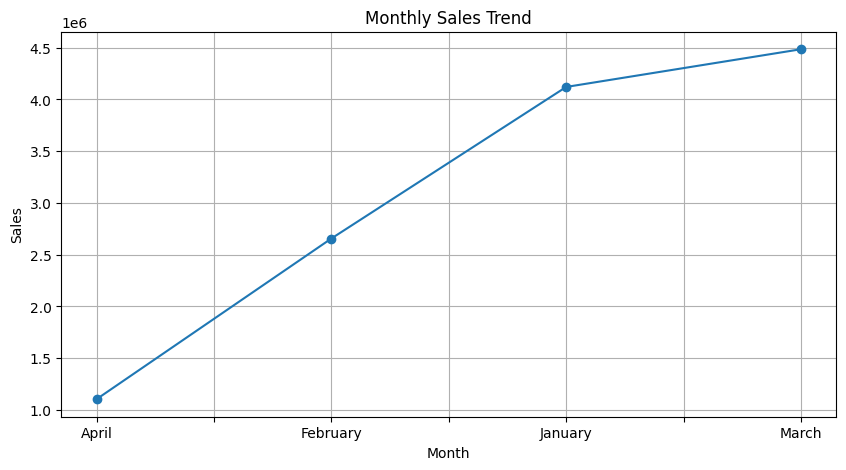

In [ ]:
# =============================================
# PART 15: VISUALIZATION - MONTHLY SALES
# =============================================

plt.figure(figsize=(10,5))
monthly_sales.plot(kind='line', marker='o')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.grid(True)
plt.show()


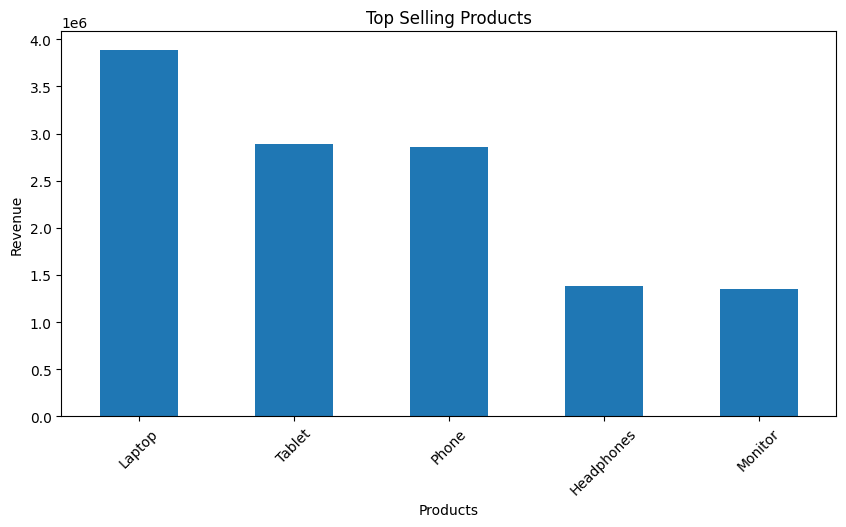

In [ ]:
# =============================================
# PART 16: VISUALIZATION - TOP PRODUCTS
# =============================================

plt.figure(figsize=(10,5))
best_products.head(10).plot(kind='bar')
plt.title('Top Selling Products')
plt.xlabel('Products')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.show()


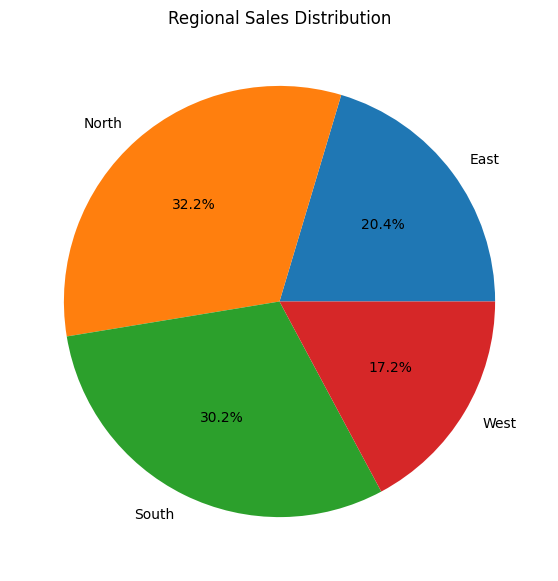

In [ ]:
# =============================================
# PART 17: VISUALIZATION - REGIONAL SALES
# =============================================

plt.figure(figsize=(7,7))
regional_sales.plot(kind='pie', autopct='%1.1f%%')
plt.title('Regional Sales Distribution')
plt.ylabel('')
plt.show()


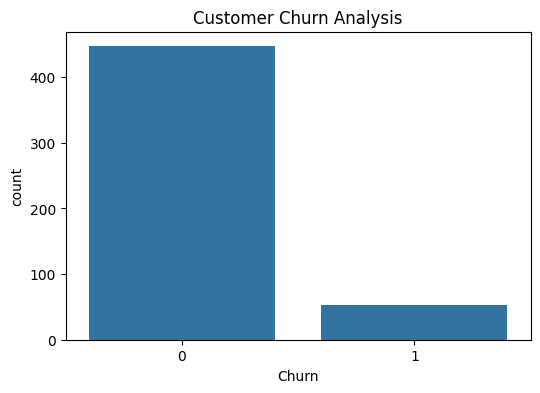

In [ ]:
# =============================================
# PART 18: VISUALIZATION - CUSTOMER CHURN
# =============================================

if 'Churn' in customer_df.columns:
    plt.figure(figsize=(6,4))
    sns.countplot(x='Churn', data=customer_df)
    plt.title('Customer Churn Analysis')
    plt.show()


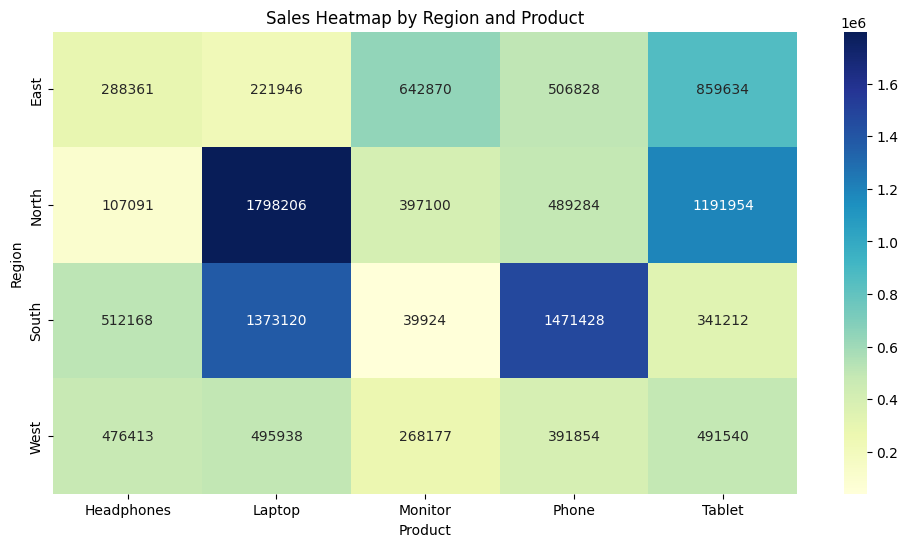

In [ ]:

# =============================================
# PART 19: VISUALIZATION - SALES HEATMAP
# =============================================

plt.figure(figsize=(12,6))
sns.heatmap(pivot_table, annot=True, fmt='.0f', cmap='YlGnBu')
plt.title('Sales Heatmap by Region and Product')
plt.show()


In [ ]:
# =============================================
# PART 20: FINAL REPORT
# =============================================

# Calculate top customers based on Lifetime_Value
top_customers = customer_ltv.sort_values(by='Lifetime_Value', ascending=False)['Lifetime_Value']

print('=========================================')
print(' CUSTOMER SALES ANALYSIS REPORT ')
print('=========================================')

print(f"Total Revenue: ${sales_df['Total_Sales'].sum():,.2f}")
print(f"Total Customers: {sales_df['Customer_ID'].nunique()}")
print(f"Average Order Value: ${sales_df['Total_Sales'].mean():,.2f}")
print(f"Top Customer Revenue: ${top_customers.iloc[0]:,.2f}")
print(f"Best Selling Product: {best_products.index[0]}")
print(f"Top Region: {regional_sales.idxmax()}")

if 'Churn' in customer_df.columns:
    print(f"Retention Rate: {retention_rate:.2f}%")

 CUSTOMER SALES ANALYSIS REPORT 
Total Revenue: $12,365,048.00
Total Customers: 100
Average Order Value: $123,650.48
Top Customer Revenue: $373,932.00
Best Selling Product: Laptop
Top Region: North
Retention Rate: 89.40%


In [ ]:
# =============================================
# PART 21: BUSINESS INSIGHTS
# =============================================

print('\nBUSINESS INSIGHTS')
print('1. Top customers generate maximum revenue.')
print('2. Some products dominate sales performance.')
print('3. Regional sales vary significantly.')
print('4. Seasonal trends affect revenue.')
print('5. Customer retention improves long-term growth.')



BUSINESS INSIGHTS
1. Top customers generate maximum revenue.
2. Some products dominate sales performance.
3. Regional sales vary significantly.
4. Seasonal trends affect revenue.
5. Customer retention improves long-term growth.


In [ ]:
# =============================================
# PART 22: BUSINESS RECOMMENDATIONS
# =============================================

print('\nRECOMMENDATIONS')
print('1. Introduce loyalty reward programs.')
print('2. Improve customer retention strategies.')
print('3. Increase promotions during low sales periods.')
print('4. Create bundled product offers.')
print('5. Focus marketing on high-performing regions.')


RECOMMENDATIONS
1. Introduce loyalty reward programs.
2. Improve customer retention strategies.
3. Increase promotions during low sales periods.
4. Create bundled product offers.
5. Focus marketing on high-performing regions.


In [ ]:
# =============================================
# PART 23: SAVE OUTPUT FILES
# =============================================

# Save Top Customers
top_customers.to_csv('top_customers.csv')

# Save Pivot Table
pivot_table.to_csv('sales_pivot_table.csv')

# Save Merged Dataset
merged_df.to_csv('merged_customer_sales_data.csv', index=False)

print('\nAll output files saved successfully!')



All output files saved successfully!
